# **the next code does:**

- Sets up project paths, random seeds, and the CPU.
- Loads the training and validation data from CSV files.
- Creates a number mapping for the 8 vehicle classes and checks the data.
- Checks that all image files exist and prints dataset information.

In [1]:
from pathlib import Path
import random
import numpy as np
import pandas as pd
import torch

PROJECT_ROOT = Path(
    r"D:\Maktab_Sharif_Projects\traffic-vehicle-classification"
)

MANIFEST_DIR = (
    PROJECT_ROOT / "data" / "neysan_experiment" / "manifests"
)

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "neysan_experiment"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
DEVICE = torch.device("cpu")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

train_df = pd.read_csv(MANIFEST_DIR / "train.csv")
val_df = pd.read_csv(MANIFEST_DIR / "validation.csv")

classes = sorted(train_df["label"].unique())
class_to_idx = {
    name: index for index, name in enumerate(classes)
}

assert len(classes) == 8
assert "neysan" not in classes
assert set(val_df["label"]) == set(classes)
assert train_df["sha256"].is_unique
assert val_df["sha256"].is_unique
assert set(train_df["sha256"]).isdisjoint(val_df["sha256"])

missing_paths = [
    path
    for path in pd.concat([train_df["path"], val_df["path"]])
    if not Path(path).is_file()
]
assert not missing_paths, f"Missing images: {missing_paths[:5]}"

print("Device:", DEVICE)
print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Class mapping:", class_to_idx)
print("Missing image paths:", len(missing_paths))
print("Output folder:", OUTPUT_DIR)

Device: cpu
Training images: 2615
Validation images: 654
Class mapping: {'ambulance': 0, 'autobus': 1, 'kamyun': 2, 'kamyunet': 3, 'minibus': 4, 'savari': 5, 'taxi': 6, 'vanet': 7}
Missing image paths: 0
Output folder: D:\Maktab_Sharif_Projects\traffic-vehicle-classification\outputs\neysan_experiment


# **the next code does:**

- Prepares images by resizing them to **224×224** while keeping their original proportions.
- Adds random **flipping and color changes** to training images to improve generalization.
- Converts images to tensors and **normalizes** their pixel values.
- Uses only fixed preprocessing for validation images to measure the model fairly.

In [2]:
from PIL import Image, ImageOps
from torchvision import transforms

IMAGE_SIZE = 224
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]


class ResizeWithPadding:
    def __init__(self, size=224, color=(124, 116, 104)):
        self.size = size
        self.color = color

    def __call__(self, image):
        resized = ImageOps.contain(
            image,
            (self.size, self.size),
            method=Image.Resampling.BILINEAR,
        )

        canvas = Image.new(
            "RGB",
            (self.size, self.size),
            self.color,
        )

        position = (
            (self.size - resized.width) // 2,
            (self.size - resized.height) // 2,
        )
        canvas.paste(resized, position)

        return canvas


train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1,
        saturation=0.1,
    ),
    ResizeWithPadding(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

val_transform = transforms.Compose([
    ResizeWithPadding(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

print("Image size: 224 × 224, proportions preserved")
print("Training augmentation: horizontal flip + color jitter")
print("Validation preprocessing: deterministic")
print("Transformations ready.")

Image size: 224 × 224, proportions preserved
Training augmentation: horizontal flip + color jitter
Validation preprocessing: deterministic
Transformations ready.


# **the next code does:**

- Creates a dataset that loads, cleans, and transforms each vehicle image.
- Builds **balanced batches** containing 2 images from each of the 8 classes (**16 images per batch**).
- Creates DataLoaders to efficiently provide training and validation images to the model.
- Finally, prints dataset sizes, batches per epoch, and batch structure.

In [3]:
import math
from torch.utils.data import Dataset, DataLoader, Sampler

BATCH_SIZE = 16


class VehicleDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        with Image.open(row["path"]) as image:
            image = ImageOps.exif_transpose(image).convert("RGB")
            image = self.transform(image)

        return image, class_to_idx[row["label"]]


class BalancedBatchSampler(Sampler):
    def __init__(
        self, labels, samples_per_class, batches_per_epoch, seed
    ):
        labels = np.asarray(labels)
        self.classes = sorted(np.unique(labels))
        self.indices = {
            label: np.flatnonzero(labels == label)
            for label in self.classes
        }
        self.samples_per_class = samples_per_class
        self.batches_per_epoch = batches_per_epoch
        self.seed = seed
        self.epoch = 0

        assert all(
            len(indices) >= samples_per_class
            for indices in self.indices.values()
        )

    def __len__(self):
        return self.batches_per_epoch

    def __iter__(self):
        rng = np.random.default_rng(self.seed + self.epoch)
        self.epoch += 1

        pools = {
            label: rng.permutation(indices)
            for label, indices in self.indices.items()
        }
        positions = {label: 0 for label in self.classes}

        for _ in range(self.batches_per_epoch):
            batch = []

            for label in self.classes:
                selected = []

                while len(selected) < self.samples_per_class:
                    start = positions[label]
                    available = len(pools[label]) - start
                    needed = self.samples_per_class - len(selected)
                    take = min(available, needed)

                    selected.extend(
                        pools[label][start:start + take].tolist()
                    )
                    positions[label] += take

                    if positions[label] == len(pools[label]):
                        pools[label] = rng.permutation(
                            self.indices[label]
                        )
                        positions[label] = 0

                batch.extend(selected)

            rng.shuffle(batch)
            yield batch


train_dataset = VehicleDataset(train_df, train_transform)
val_dataset = VehicleDataset(val_df, val_transform)

train_sampler = BalancedBatchSampler(
    labels=train_df["label"].to_numpy(),
    samples_per_class=2,
    batches_per_epoch=math.ceil(len(train_dataset) / BATCH_SIZE),
    seed=SEED,
)

train_generator = torch.Generator().manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_sampler=train_sampler,
    num_workers=0,
    generator=train_generator,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Training batches per epoch:", len(train_loader))
print("Image draws per training epoch:", len(train_loader) * BATCH_SIZE)
print("Balanced batch: 8 classes × 2 images = 16")
print("Loaders ready.")

Training images: 2615
Validation images: 654
Training batches per epoch: 164
Image draws per training epoch: 2624
Balanced batch: 8 classes × 2 images = 16
Loaders ready.


# **the next code does:**

- Loads a pretrained **ResNet18** model with ImageNet weights.
- Replaces its classifier with **Dropout (0.25) + a Linear layer** for the 8 vehicle classes.
- Freezes most layers and trains only **layer3, layer4, and the classifier**.
- Sets the model's training behavior and moves it to the selected device (CPU).

In [4]:
from torch import nn
from torchvision import models

torch.manual_seed(SEED)

model = models.resnet18(
    weights=models.ResNet18_Weights.IMAGENET1K_V1
)

model.fc = nn.Sequential(
    nn.Dropout(p=0.25),
    nn.Linear(model.fc.in_features, len(classes)),
)

for parameter in model.parameters():
    parameter.requires_grad = False

for layer_name in ["layer3", "layer4", "fc"]:
    for parameter in getattr(model, layer_name).parameters():
        parameter.requires_grad = True

model = model.to(DEVICE)


def set_training_mode():
    model.eval()

    for layer_name in ["layer3", "layer4", "fc"]:
        getattr(model, layer_name).train()

    for module in model.modules():
        if isinstance(module, nn.modules.batchnorm._BatchNorm):
            module.eval()


trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print("Architecture: ResNet18")
print("Initialization: ImageNet pretrained weights")
print("Output classes:", len(classes))
print("Classifier:", model.fc)
print("Trainable layers: layer3 + layer4 + fc")
print("Trainable parameters:", trainable_parameters)
print("Device:", DEVICE)

Architecture: ResNet18
Initialization: ImageNet pretrained weights
Output classes: 8
Classifier: Sequential(
  (0): Dropout(p=0.25, inplace=False)
  (1): Linear(in_features=512, out_features=8, bias=True)
)
Trainable layers: layer3 + layer4 + fc
Trainable parameters: 10497544
Device: cpu


# **the next code does:**

- Defines the training settings, including **30 epochs, learning rates, dropout, and weight decay**.
- Creates the **AdamW optimizer**, **BCEWithLogitsLoss**, and a learning-rate scheduler.
- Uses **one-hot labels** so BCE can calculate the loss for the 8 classes.
- Saves all training settings into a **JSON recipe** for reproducibility.

In [6]:
import json
import torch.nn.functional as F

EPOCHS = 30

TRAINING_CONFIG = {
    "architecture": "resnet18",
    "initialization": "imagenet",
    "trainable_layers": ["layer3", "layer4", "fc"],
    "dropout": 0.25,
    "loss": "bce",
    "sampling": "balanced",
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "layer3_lr": 3e-6,
    "layer4_lr": 1e-5,
    "fc_lr": 1e-3,
    "weight_decay": 1e-4,
    "scheduler": "ReduceLROnPlateau",
    "scheduler_monitor": "validation_macro_f1",
    "batchnorm_running_stats": "fixed",
    "seed": SEED,
    "image_size": IMAGE_SIZE,
    "mean": MEAN,
    "std": STD,
    "padding_color": [124, 116, 104],
    "horizontal_flip_probability": 0.5,
    "color_jitter": {
        "brightness": 0.1,
        "contrast": 0.1,
        "saturation": 0.1,
    },
    "training_images": len(train_df),
    "validation_images": len(val_df),
    "checkpoint_rule": "macro_f1_then_accuracy_then_lower_loss",
    "human_check_threshold": 0.8,
    "confidence_method": "uncalibrated_sigmoid_score",
}

optimizer = torch.optim.AdamW(
    [
        {
            "params": model.layer3.parameters(),
            "lr": TRAINING_CONFIG["layer3_lr"],
        },
        {
            "params": model.layer4.parameters(),
            "lr": TRAINING_CONFIG["layer4_lr"],
        },
        {
            "params": model.fc.parameters(),
            "lr": TRAINING_CONFIG["fc_lr"],
        },
    ],
    weight_decay=TRAINING_CONFIG["weight_decay"],
)

criterion = nn.BCEWithLogitsLoss()


def classification_loss(logits, labels):
    targets = F.one_hot(
        labels, num_classes=len(classes)
    ).to(dtype=logits.dtype)

    return criterion(logits, targets)


scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2,
    threshold=0.0,
    threshold_mode="abs",
)

recipe_path = OUTPUT_DIR / "training_recipe.json"

with recipe_path.open("w", encoding="utf-8") as file:
    json.dump(TRAINING_CONFIG, file, indent=2)

print("Epochs:", EPOCHS)
print("Loss: BCEWithLogitsLoss with one-hot targets")
print("Optimizer: AdamW")
print("Layer 3 learning rate:", optimizer.param_groups[0]["lr"])
print("Layer 4 learning rate:", optimizer.param_groups[1]["lr"])
print("FC learning rate:", optimizer.param_groups[2]["lr"])
print("Scheduler: halve learning rates after 3 epochs without")
print("           improvement in validation macro-F1")
print("Recipe saved:", recipe_path)

Epochs: 30
Loss: BCEWithLogitsLoss with one-hot targets
Optimizer: AdamW
Layer 3 learning rate: 3e-06
Layer 4 learning rate: 1e-05
FC learning rate: 0.001
Scheduler: halve learning rates after 3 epochs without
           improvement in validation macro-F1
Recipe saved: D:\Maktab_Sharif_Projects\traffic-vehicle-classification\outputs\neysan_experiment\training_recipe.json


# **the next code does:**

- Defines the **training and validation loop** and calculates accuracy, F1, precision, and recall.
- Trains the model for **20 epochs**, updates the weights, and reduces the learning rate when validation F1 stops improving.
- Saves the **best and latest model checkpoints** plus the training history.
- Keeps **Neysan images completely separate**, so they are not used during training or validation.

In [7]:
import copy
import time
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
)

BEST_PATH = OUTPUT_DIR / "resnet18_neysan_best.pt"
LATEST_PATH = OUTPUT_DIR / "resnet18_neysan_latest.pt"
HISTORY_PATH = OUTPUT_DIR / "training_history.csv"


def save_checkpoint_atomic(checkpoint, path):
    temporary_path = path.with_suffix(".tmp")
    torch.save(checkpoint, temporary_path)
    temporary_path.replace(path)


def validate_model():
    model.eval()

    total_loss = 0.0
    total_count = 0
    true_labels = []
    predictions = []

    with torch.inference_mode():
        for images, labels in val_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            logits = model(images)
            loss = classification_loss(logits, labels)

            if not torch.isfinite(loss):
                raise RuntimeError("Non-finite validation loss.")

            count = labels.size(0)
            total_loss += loss.item() * count
            total_count += count

            true_labels.extend(labels.cpu().tolist())
            predictions.extend(logits.argmax(1).cpu().tolist())

    precision, recall, f1, support = (
        precision_recall_fscore_support(
            true_labels,
            predictions,
            labels=list(range(len(classes))),
            average=None,
            zero_division=0,
        )
    )

    vanet_index = class_to_idx["vanet"]

    return {
        "val_loss": total_loss / total_count,
        "val_accuracy": float(
            accuracy_score(true_labels, predictions)
        ),
        "val_macro_f1": float(f1.mean()),
        "vanet_recall": float(recall[vanet_index]),
        "vanet_f1": float(f1[vanet_index]),
        "per_class": {
            name: {
                "precision": float(precision[index]),
                "recall": float(recall[index]),
                "f1": float(f1[index]),
                "support": int(support[index]),
            }
            for index, name in enumerate(classes)
        },
    }


def train_model():
    for path in [BEST_PATH, LATEST_PATH, HISTORY_PATH]:
        if path.exists():
            raise FileExistsError(
                f"Existing result: {path}\n"
                "Preserve or move existing results before a new run."
            )

    assert EPOCHS == TRAINING_CONFIG["epochs"]

    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    train_sampler.epoch = 0
    train_generator.manual_seed(SEED)

    history = []
    best_key = None
    best_epoch = None

    for epoch in range(1, EPOCHS + 1):
        started = time.perf_counter()
        set_training_mode()

        learning_rates = [
            group["lr"] for group in optimizer.param_groups
        ]

        total_loss = 0.0
        total_correct = 0
        total_count = 0

        for images, labels in train_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            optimizer.zero_grad(set_to_none=True)

            logits = model(images)
            loss = classification_loss(logits, labels)

            if not torch.isfinite(loss):
                raise RuntimeError(
                    f"Non-finite training loss at epoch {epoch}."
                )

            loss.backward()
            optimizer.step()

            count = labels.size(0)
            total_loss += loss.item() * count
            total_correct += (
                logits.argmax(1) == labels
            ).sum().item()
            total_count += count

        validation = validate_model()

        key = (
            validation["val_macro_f1"],
            validation["val_accuracy"],
            -validation["val_loss"],
        )
        improved = best_key is None or key > best_key

        if improved:
            best_key = key
            best_epoch = epoch

        scheduler.step(validation["val_macro_f1"])

        row = {
            "epoch": epoch,
            "train_loss": total_loss / total_count,
            "train_accuracy": total_correct / total_count,
            "val_loss": validation["val_loss"],
            "val_accuracy": validation["val_accuracy"],
            "val_macro_f1": validation["val_macro_f1"],
            "vanet_recall": validation["vanet_recall"],
            "vanet_f1": validation["vanet_f1"],
            "layer3_lr": learning_rates[0],
            "layer4_lr": learning_rates[1],
            "fc_lr": learning_rates[2],
            "seconds": time.perf_counter() - started,
        }
        history.append(row)

        checkpoint = {
            "epoch": epoch,
            "stage": "neysan_holdout_training",
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "class_to_idx": dict(class_to_idx),
            "config": copy.deepcopy(TRAINING_CONFIG),
            "val_metrics": validation,
            "best_epoch": best_epoch,
            "best_selection_key": best_key,
            "training_sha256": sorted(
                train_df["sha256"].astype(str).tolist()
            ),
            "validation_sha256": sorted(
                val_df["sha256"].astype(str).tolist()
            ),
        }

        if improved:
            save_checkpoint_atomic(checkpoint, BEST_PATH)

        save_checkpoint_atomic(checkpoint, LATEST_PATH)

        history_table = pd.DataFrame(history)
        temporary_history = HISTORY_PATH.with_suffix(".tmp")
        history_table.to_csv(temporary_history, index=False)
        temporary_history.replace(HISTORY_PATH)

        print(
            f"Epoch {epoch:02d}/{EPOCHS} | "
            f"Train loss: {row['train_loss']:.4f} | "
            f"Train accuracy: {row['train_accuracy']:.2%} | "
            f"Val accuracy: {row['val_accuracy']:.2%} | "
            f"Val macro-F1: {row['val_macro_f1']:.4f} | "
            f"Vanet recall: {row['vanet_recall']:.2%} | "
            f"Vanet F1: {row['vanet_f1']:.4f} | "
            f"{row['seconds']:.1f}s"
            + (" | BEST" if improved else ""),
            flush=True,
        )

    print("\nTraining completed.")
    print("Best epoch:", best_epoch)
    print(f"Best validation macro-F1: {best_key[0]:.4f}")
    print(f"Best validation accuracy: {best_key[1]:.2%}")
    print("Best checkpoint:", BEST_PATH)
    print("History:", HISTORY_PATH)

    return pd.DataFrame(history)


print("Training loop ready.")
print("Epochs:", EPOCHS)
print("Neysan images are not used in training or validation.")

Training loop ready.
Epochs: 30
Neysan images are not used in training or validation.


In [8]:
history = train_model()

Epoch 01/30 | Train loss: 0.2286 | Train accuracy: 66.27% | Val accuracy: 86.24% | Val macro-F1: 0.8529 | Vanet recall: 100.00% | Vanet F1: 0.6139 | 418.8s | BEST
Epoch 02/30 | Train loss: 0.0793 | Train accuracy: 92.04% | Val accuracy: 94.04% | Val macro-F1: 0.9361 | Vanet recall: 100.00% | Vanet F1: 0.8493 | 438.3s | BEST
Epoch 03/30 | Train loss: 0.0511 | Train accuracy: 94.82% | Val accuracy: 94.95% | Val macro-F1: 0.9491 | Vanet recall: 100.00% | Vanet F1: 0.9254 | 445.5s | BEST
Epoch 04/30 | Train loss: 0.0371 | Train accuracy: 96.61% | Val accuracy: 95.11% | Val macro-F1: 0.9452 | Vanet recall: 100.00% | Vanet F1: 0.8611 | 413.9s
Epoch 05/30 | Train loss: 0.0282 | Train accuracy: 97.45% | Val accuracy: 95.87% | Val macro-F1: 0.9588 | Vanet recall: 100.00% | Vanet F1: 0.9538 | 412.6s | BEST
Epoch 06/30 | Train loss: 0.0204 | Train accuracy: 98.67% | Val accuracy: 96.02% | Val macro-F1: 0.9570 | Vanet recall: 96.77% | Vanet F1: 0.9375 | 434.6s
Epoch 07/30 | Train loss: 0.0170 | Tr

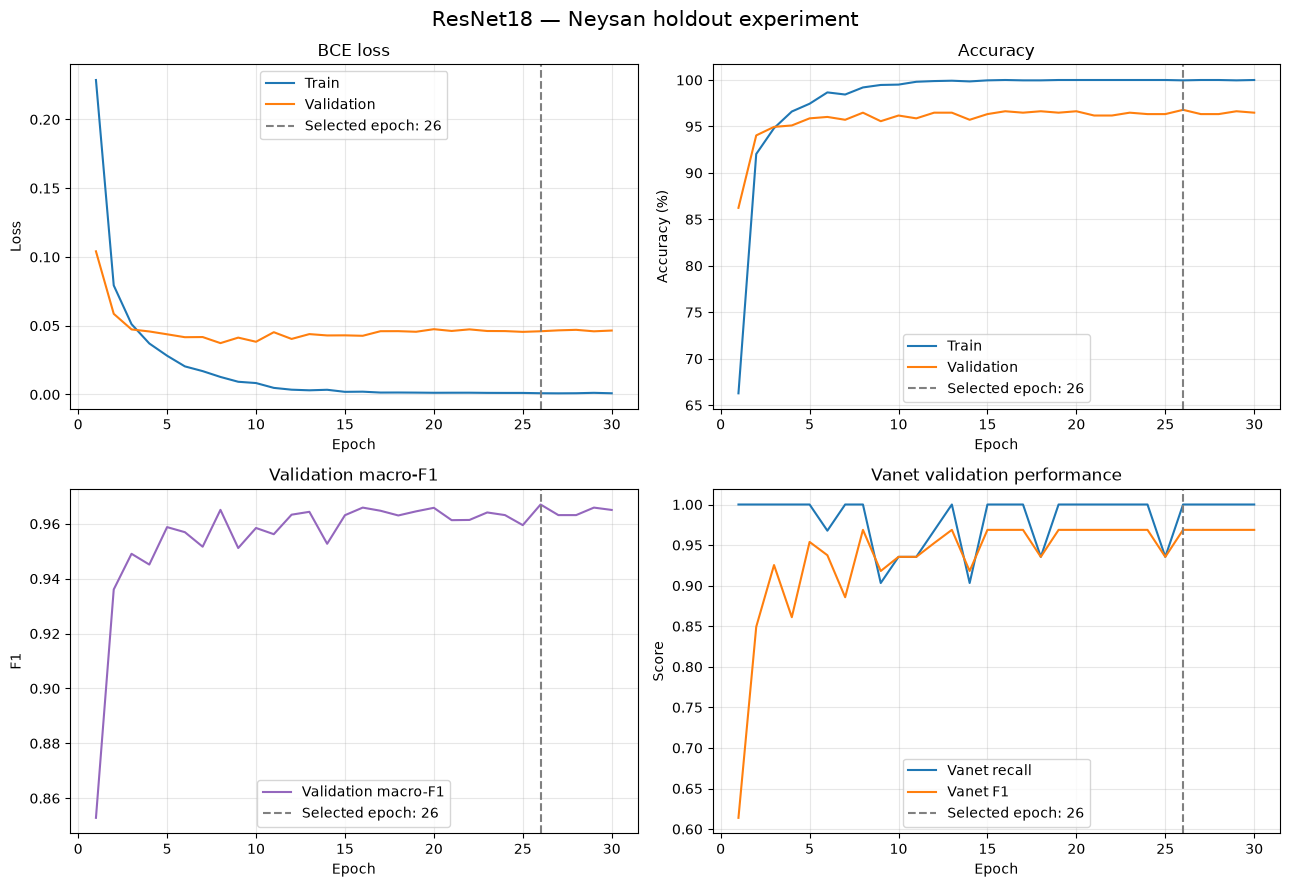

Figure saved: D:\Maktab_Sharif_Projects\traffic-vehicle-classification\outputs\neysan_experiment\training_curves.png
Selected epoch: 26
Total training time: 208.6 minutes


,precision,recall,f1,support
ambulance,1.000000,0.987805,0.993865,82.0
autobus,0.990385,0.990385,0.990385,104.0
kamyun,0.965116,0.954023,0.959538,87.0
kamyunet,0.967213,0.959350,0.963265,123.0
minibus,0.965116,0.954023,0.959538,87.0
savari,0.918919,0.971429,0.944444,70.0
taxi,0.970588,0.942857,0.956522,70.0
vanet,0.939394,1.000000,0.968750,31.0


In [9]:
import matplotlib.pyplot as plt

history = pd.read_csv(OUTPUT_DIR / "training_history.csv")

best_checkpoint = torch.load(
    OUTPUT_DIR / "resnet18_neysan_best.pt",
    map_location="cpu",
    weights_only=True,
)
best_epoch = best_checkpoint["epoch"]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0, 0].plot(
    history["epoch"], history["train_loss"], label="Train"
)
axes[0, 0].plot(
    history["epoch"], history["val_loss"], label="Validation"
)
axes[0, 0].set_title("BCE loss")
axes[0, 0].set_ylabel("Loss")

axes[0, 1].plot(
    history["epoch"],
    history["train_accuracy"] * 100,
    label="Train",
)
axes[0, 1].plot(
    history["epoch"],
    history["val_accuracy"] * 100,
    label="Validation",
)
axes[0, 1].set_title("Accuracy")
axes[0, 1].set_ylabel("Accuracy (%)")

axes[1, 0].plot(
    history["epoch"],
    history["val_macro_f1"],
    label="Validation macro-F1",
    color="tab:purple",
)
axes[1, 0].set_title("Validation macro-F1")
axes[1, 0].set_ylabel("F1")

axes[1, 1].plot(
    history["epoch"],
    history["vanet_recall"],
    label="Vanet recall",
)
axes[1, 1].plot(
    history["epoch"],
    history["vanet_f1"],
    label="Vanet F1",
)
axes[1, 1].set_title("Vanet validation performance")
axes[1, 1].set_ylabel("Score")

for ax in axes.flat:
    ax.axvline(
        best_epoch,
        color="gray",
        linestyle="--",
        label=f"Selected epoch: {best_epoch}",
    )
    ax.set_xlabel("Epoch")
    ax.grid(alpha=0.3)
    ax.legend()

fig.suptitle(
    "ResNet18 — Neysan holdout experiment",
    fontsize=15,
)
fig.tight_layout()

figure_path = OUTPUT_DIR / "training_curves.png"
fig.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figure saved:", figure_path)
print("Selected epoch:", best_epoch)
print(
    "Total training time:",
    f"{history['seconds'].sum() / 60:.1f} minutes",
)

display(
    pd.DataFrame(best_checkpoint["val_metrics"]["per_class"]).T
)